# Time series forecast (temperature)

In [40]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [41]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

MERGED_PATH = PROCESSED_DIR / "minimum_hourly_merged.csv"
STATION_ID = "72502014734"

DECOMP_PERIOD = 24
ACF_LAGS = 48
ACF_TRIM = 5000

SARIMAX_ORDER = (1, 1, 1)
SARIMAX_SEASONAL = (1, 0, 1, 24)
SARIMA_TRAIN_FRAC = 0.92
SARIMA_MAXITER = 100
# None = fit on entire temp_hourly (slow); else last N hourly points used for modeling only.
SARIMA_FIT_TAIL_H = 24 * 400


In [42]:
# drop if empty row, average out hourly (so that it's strictly on the hour), interpolate if needed
def station_temp_hourly(merged_csv, station_id):
    df = pd.read_csv(merged_csv)
    df["date_local"] = pd.to_datetime(df["date_local"], utc=True, errors="coerce")
    df = df.dropna(subset=["date_local", "met_TMP"])
    sel = df[df["station_id"].astype(str) == str(station_id)].copy()
    if sel.empty:
        raise ValueError(f"no rows for station_id={station_id!r}")
    sel = sel.sort_values("date_local").set_index("date_local")
    raw = sel["met_TMP"].astype("float64")
    hourly = raw.resample("1h").mean()
    return hourly.interpolate(limit_direction="both")


In [43]:
temp_hourly = station_temp_hourly(MERGED_PATH, STATION_ID)

temp_hourly.head()


date_local
2020-01-01 00:00:00+00:00    6.70
2020-01-01 01:00:00+00:00    6.15
2020-01-01 02:00:00+00:00    5.60
2020-01-01 03:00:00+00:00    5.60
2020-01-01 04:00:00+00:00    5.00
Freq: h, Name: met_TMP, dtype: float64

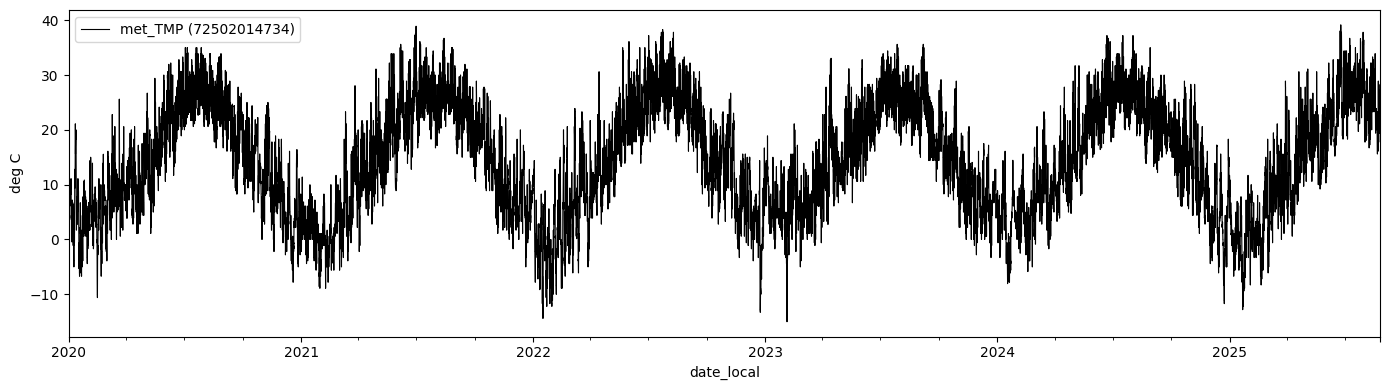

In [44]:
fig, ax = plt.subplots(figsize=(14, 4))
temp_hourly.plot(ax=ax, color="black", lw=0.8, label=f"met_TMP ({STATION_ID})")
ax.set_ylabel("deg C")
ax.legend()
plt.tight_layout()
plt.show()

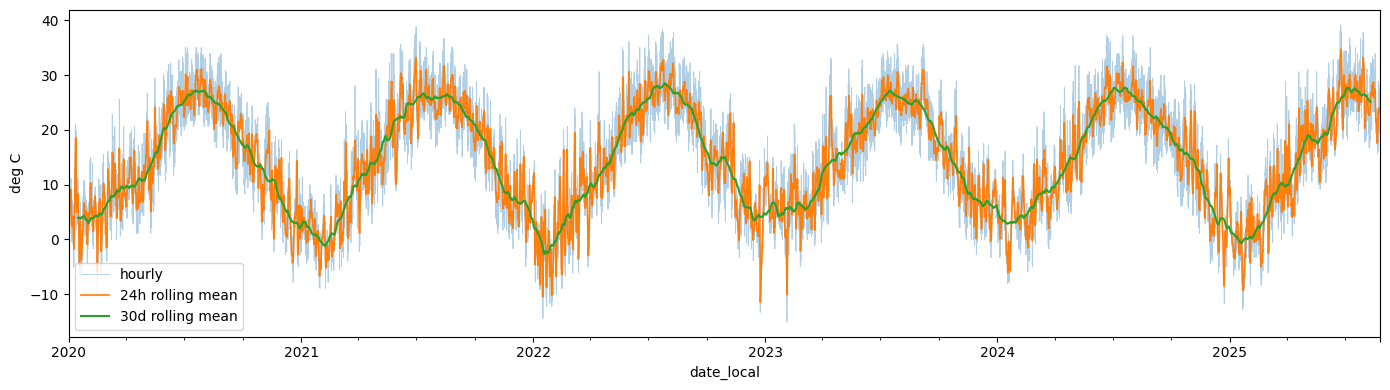

In [45]:
# Rolling means vs hourly
roll24 = temp_hourly.rolling(24, center=True).mean()
roll_month = temp_hourly.rolling(24 * 30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
temp_hourly.plot(ax=ax, alpha=0.35, lw=0.6, label="hourly")
roll24.plot(ax=ax, lw=1.2, label="24h rolling mean")
roll_month.plot(ax=ax, lw=1.5, label="30d rolling mean")
ax.set_ylabel("deg C")
ax.legend()
plt.tight_layout()
plt.show()


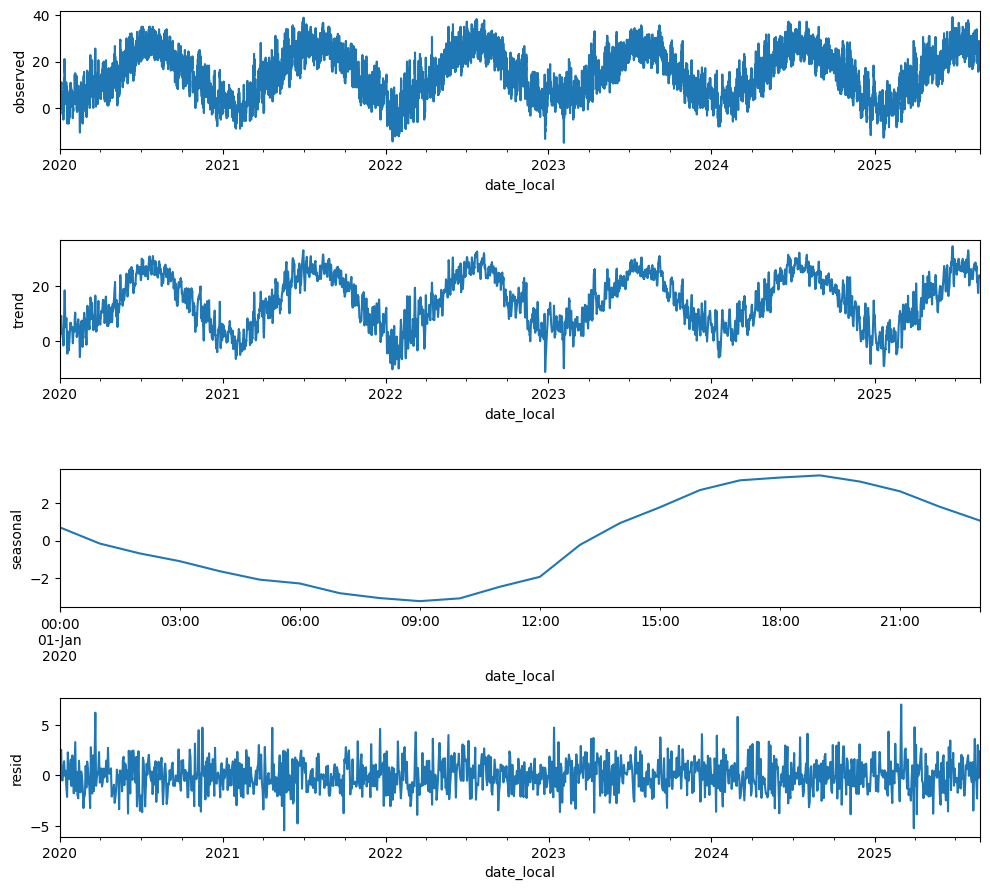

In [46]:
# Decompose + resids
decomp = seasonal_decompose(
    temp_hourly,
    model="additive",
    period=DECOMP_PERIOD,
    extrapolate_trend="freq",
)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=False)

temp_hourly.plot(ax=axes[0])
axes[0].set_ylabel("observed")

decomp.trend.plot(ax=axes[1])
axes[1].set_ylabel("trend")

decomp.seasonal.iloc[:24].plot(ax=axes[2]) # daily seasonal
axes[2].set_ylabel("seasonal")

decomp.resid.iloc[::40].plot(ax=axes[3]) # step size 40 just to make it readable
axes[3].set_ylabel("resid")

plt.tight_layout()
plt.show()


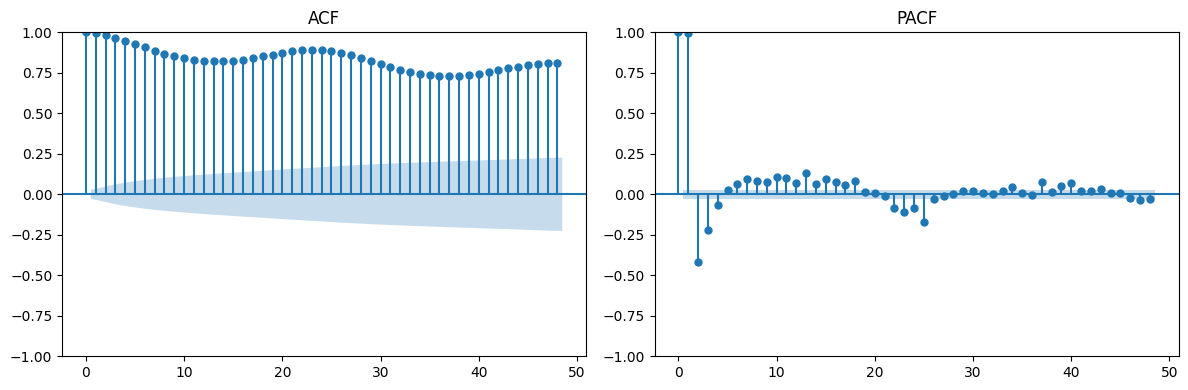

In [ ]:
n_acf = min(len(temp_hourly), ACF_TRIM)
acf_input = temp_hourly.iloc[:n_acf] - temp_hourly.iloc[:n_acf].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(acf_input, ax=axes[0], lags=ACF_LAGS, title="ACF")
plot_pacf(acf_input, ax=axes[1], lags=ACF_LAGS, method="ywm", title="PACF")
plt.tight_layout()
plt.show()

In [ ]:
# Optional tail window, train/test split, SARIMAX fit, multi-step forecasts over the held-out slice.
sarima_series = temp_hourly
if SARIMA_FIT_TAIL_H is not None:
    sarima_series = temp_hourly.iloc[-SARIMA_FIT_TAIL_H:]

split = max(int(len(sarima_series) * SARIMA_TRAIN_FRAC), 72)
split = min(split, len(sarima_series) - 50)
y_train = sarima_series.iloc[:split]
y_test = sarima_series.iloc[split:]

model = SARIMAX(
    y_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    sarima_res = model.fit(disp=False, maxiter=SARIMA_MAXITER)

forecast = sarima_res.get_forecast(steps=len(y_test))
sarima_pred = forecast.predicted_mean

sarima_mae = np.mean(np.abs(y_test.values - sarima_pred.values))
sarima_mae


In [ ]:
# Compare actual test temps to SARIMAX forecasts over the start of the test window.
plot_h = min(24 * 14, len(y_test))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index[:plot_h], y_test.iloc[:plot_h], label="actual", lw=1, color="black")
ax.plot(
    sarima_pred.index[:plot_h],
    sarima_pred.iloc[:plot_h],
    label="SARIMAX forecast",
    lw=1,
)
ax.legend()
plt.tight_layout()
plt.show()
